In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from pathlib import Path

In [3]:
pwd

'/home/lotus/projects/1.5.1ml_simple_QSAR/data/NSD2'

In [4]:
sns.set_theme(style="white")

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Cambria','Times New Roman', 'Times', 'DejaVu Serif'],
    'svg.fonttype': 'none',   # 保持字体可编辑
})

# 输出目录
output_dir = Path("./cluster")
output_dir.mkdir(parents=True, exist_ok=True)

In [5]:
file_path = './nsd2_final_dataset.csv'
df = pd.read_csv(file_path)

df['label'] = pd.to_numeric(df['label'], errors='coerce').fillna(0).astype(int)

print(f"Dataset loaded: {df.shape}")

Dataset loaded: (530, 9)


In [6]:
# 4. Morgan Fingerprints（新API）
fpgen = GetMorganGenerator(radius=2, fpSize=2048)

def get_fp(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return np.zeros(2048, dtype=int)
    
    fp = fpgen.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

print("Generating fingerprints...")
X = np.vstack([get_fp(s) for s in df['smiles']])
print(f"Fingerprint matrix: {X.shape}")

Generating fingerprints...
Fingerprint matrix: (530, 2048)


In [7]:
# 5. Standardization + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance (50 PCs): {pca.explained_variance_ratio_.sum():.3f}")

Explained variance (50 PCs): 0.468


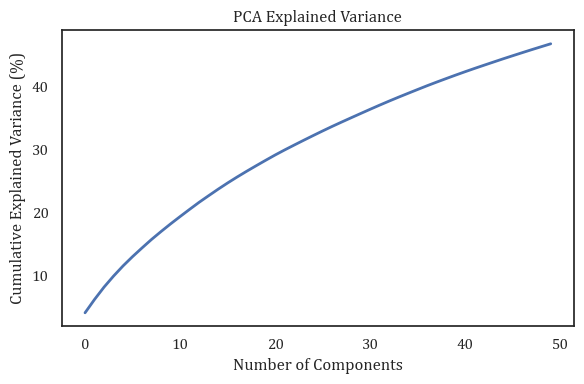

In [8]:
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, lw=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Explained Variance')

plt.tight_layout()
plt.savefig(output_dir / "Figure_S1_PCA_variance.svg", bbox_inches='tight')
plt.show()


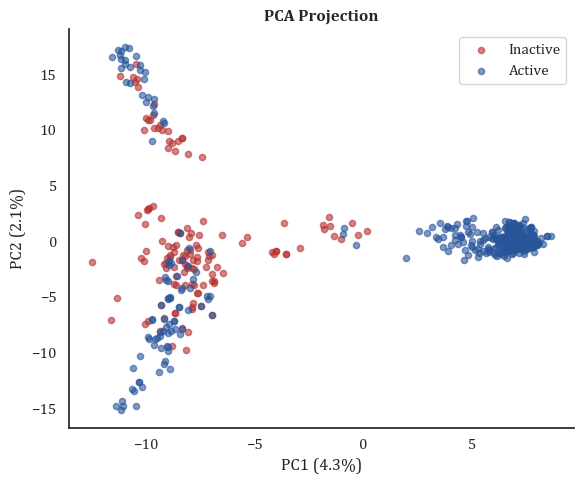

In [9]:
# 7. PCA Scatter
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

palette = {1: '#28559A', 0: '#B73131'}

fig, ax = plt.subplots(figsize=(6,5))

for val in [0,1]:
    subset = df[df['label']==val]
    ax.scatter(subset['PC1'], subset['PC2'],
               color=palette[val],
               s=20, alpha=0.6,
               label='Active' if val==1 else 'Inactive')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Projection', fontweight='bold')

ax.legend(frameon=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=5, width=1)

plt.tight_layout()
plt.savefig(output_dir / "Figure_S1_PCA_scatter.svg", bbox_inches='tight')
plt.show()

In [10]:
# 8. t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(X_pca)

df['tsne_1'] = X_tsne[:, 0]
df['tsne_2'] = X_tsne[:, 1]

cluster optimization plot saved in cluster


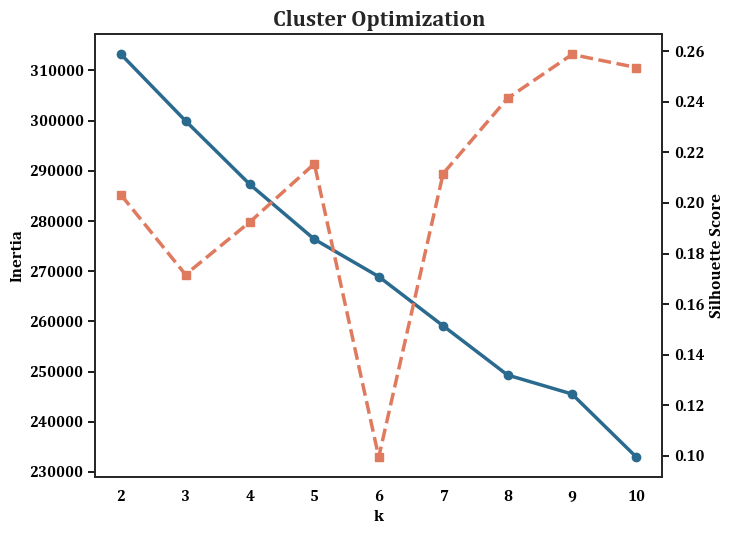

In [13]:
# 9. Clustering Evaluation（在 PCA 空间）
k_range = range(2, 11)
inertia = []
silhouette_avg = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    inertia.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_pca, labels))

# Plot
fig, ax1 = plt.subplots(figsize=(7.5, 5.5))  # 稍微加大一点画布，更好看

# 全局加粗字体
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# 莫兰迪学术色系（仅用于线条）
color_inertia = '#2A6A8F'      # 莫兰迪蓝
color_silhouette = '#E07A5F'   # 莫兰迪珊瑚橙

ax1.plot(k_range, inertia, 'o-', lw=2.5, color=color_inertia, label='Inertia')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_avg, 's--', lw=2.5, color=color_silhouette, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score')

# 图标题
ax1.set_title('Cluster Optimization', fontsize=16)

# === 关键修复部分 ===
# x轴刻度线朝外 + 显示
ax1.tick_params(axis='x', direction='out', length=6, width=1.2, color='black')
ax2.tick_params(axis='x', direction='out', length=6, width=1.2, color='black')

# y轴刻度只显示，不改变颜色（保持黑色）
ax1.tick_params(axis='y', direction='out', length=5, color='black')
ax2.tick_params(axis='y', direction='out', length=5, color='black')

# 确保所有文字都是黑色（覆盖之前可能残留的颜色）
ax1.yaxis.label.set_color('black')
ax2.yaxis.label.set_color('black')
ax1.xaxis.label.set_color('black')

# 手动加粗所有刻度文字
for label in (ax1.get_xticklabels() + ax1.get_yticklabels() + 
              ax2.get_yticklabels()):
    label.set_fontweight('bold')
    label.set_color('black')

plt.tight_layout()
plt.savefig(output_dir / "Figure_S2_cluster_optimization.svg", bbox_inches='tight', dpi=300)
print(f"cluster optimization plot saved in {output_dir}")
plt.show()

In [14]:
# 10. Final Clustering
manual_k = 8 # adjust based on elbow/silhouette

kmeans_final = KMeans(n_clusters=manual_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_pca)
df['cluster_id'] = df['cluster'] + 1

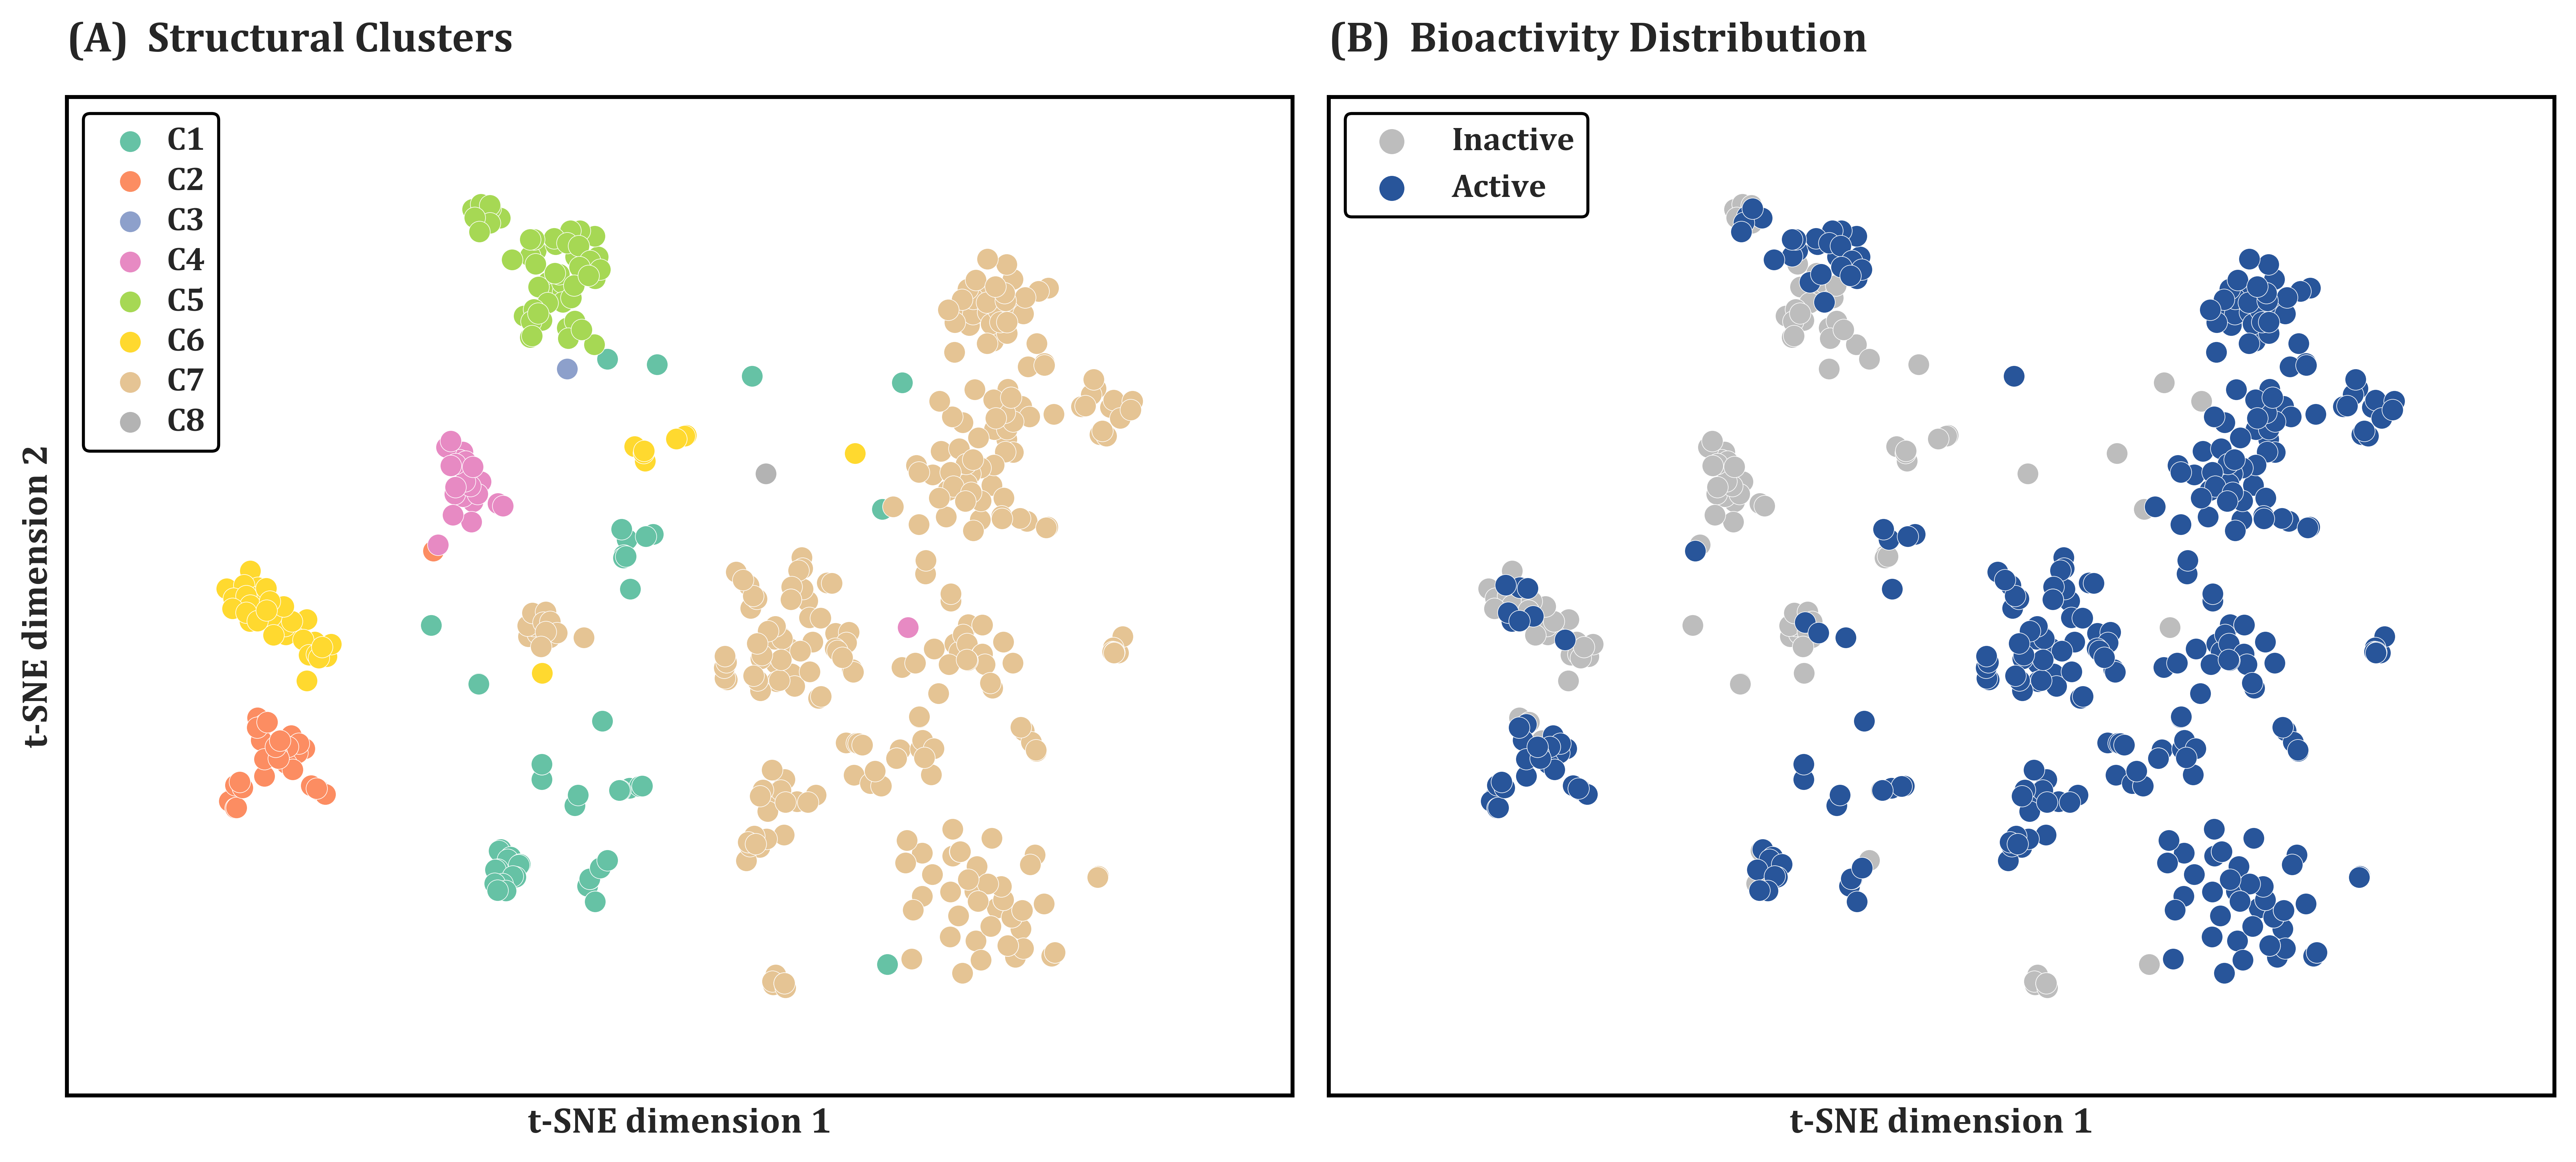

In [15]:
# %% 
# 11. Final Visualization
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Cambria','Times New Roman'],
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'savefig.dpi': 600,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), dpi=600)

# --- A. Clusters ---
cluster_colors = sns.color_palette("Set2", manual_k) 

for i in range(manual_k):
    subset = df[df['cluster'] == i]
    ax1.scatter(
        subset['tsne_1'], subset['tsne_2'],
        color=cluster_colors[i],
        s=50, alpha=1,
        edgecolors='white', linewidths=0.2,
        label=f'C{i+1}'
    )

ax1.set_title('(A)  Structural Clusters', loc='left', fontweight='bold', pad=15)
ax1.set_xlabel('t-SNE dimension 1')
ax1.set_ylabel('t-SNE dimension 2')

# 图例
ax1.legend(frameon=True, ncol=1, loc='upper left', markerscale=1, 
           facecolor='white', edgecolor='black', framealpha=1,
           handletextpad=0.1, labelspacing = 0.3, borderpad=0.4
           )

# --- B. Activity ---
activity_colors = {1: '#28559A', 0: '#BDBDBD'} 

for val in [0, 1]:
    subset = df[df['label'] == val]
    ax2.scatter(
        subset['tsne_1'], subset['tsne_2'],
        color=activity_colors[val],
        #s=20 if val == 1 else 12,
        s=50,
        #alpha=0.8 if val == 1 else 0.4,
        alpha=1,
        edgecolors='white',linewidths=0.2,
        label='Active' if val == 1 else 'Inactive',
        zorder=2 if val == 1 else 1
    )

ax2.set_title('(B)  Bioactivity Distribution', loc='left', fontweight='bold', pad=15)
ax2.set_xlabel('t-SNE dimension 1')
ax2.set_yticks([]) # 保持整洁，隐藏右图 Y 轴刻度

# 图例框起来
ax2.legend(frameon=True, loc='upper left', markerscale=1.2, 
           facecolor='white', edgecolor='black', framealpha=1)

for ax in [ax1, ax2]:
    ax.margins(0.05)
    # 开启所有边框
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.3)
        ax.spines[spine].set_color('black')
    
    # 移除数值但保留刻度线（Tick marks）
    ax.set_xticks([])
    ax.set_yticks([]) # 如果 ax1 需要 y 轴刻度，可以单独设
    
    # 保持刻度向外
    ax.tick_params(which='both', direction='out', top=True, right=True, length=4)

    # 锁定比例但允许自动调整范围
    ax.set_aspect('equal', adjustable='datalim')
    

plt.tight_layout(w_pad=1) # 左右图间距
plt.savefig(output_dir / "Figure_2_TSNE_cluster_activity.svg", format='svg', bbox_inches='tight')
plt.show()

In [16]:
# 12. Cluster Enrichment
print("\nCluster Activity Enrichment:")
enrichment = df.groupby('cluster_id')['label'].mean().sort_values(ascending=False)
print(enrichment)


Cluster Activity Enrichment:
cluster_id
7    0.943396
2    0.903226
1    0.550000
5    0.509434
6    0.190476
3    0.000000
4    0.000000
8    0.000000
Name: label, dtype: float64


In [17]:
# 13. Scaffold Analysis
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    return None

df['scaffold'] = df['smiles'].apply(get_scaffold)

# 14. Scaffold Summary（加入活性比例）
scaffold_summary = (
    df.groupby(['cluster_id', 'scaffold'])
      .agg(
          count=('label', 'size'),
          active_ratio=('label', 'mean')
      )
      .reset_index()
)

# 15. Top scaffolds per cluster（Top 3）
top_scaffold = (
    scaffold_summary
    .sort_values(['cluster_id', 'count'], ascending=[True, False])
    .groupby('cluster_id')
    .head(3)
)

print("\nTop scaffolds per cluster:")
print(top_scaffold)


Top scaffolds per cluster:
     cluster_id                                           scaffold  count  \
35            1                        c1ccc(Oc2ccc3[nH]ccc3c2)cc1      4   
8             1                      O=C1C(N2CCC2)=CC(=O)c2ncccc21      3   
10            1                O=C1C(NC23CC(C2)C3)=CC(=O)c2ncccc21      3   
52            2             O=C1COc2cc(-c3[nH]cnc3-c3ccccc3)ccc2N1      9   
40            2  O=C1COc2cc(-c3[nH]cnc3-c3ccc(CN4CCCCC4)cc3)ccc2N1      3   
50            2  O=C1COc2cc(-c3[nH]cnc3-c3cccc(CNCC4CCO4)c3)ccc2N1      2   
58            3  O=C(NS(=O)(=O)c1ccc(NCC2CCOCC2)cc1)c1ccc(N2CCN...      1   
68            4       O=S(=O)(NCc1ccccc1)c1cccc2c(NC3CCNCC3)cccc12      5   
70            4                  O=S(=O)(NCc1ccccc1)c1cccc2ccccc12      5   
59            4                      O=C(NCc1ccccc1)c1cccc2ccccc12      1   
88            5                          c1ccc2c(NC3CCNCC3)ncnc2c1     14   
76            5             c1cc(NC2CCNCC2)c2ccc

In [18]:
n_compounds = len(df)

n_scaffolds = df['scaffold'].nunique()

scaffold_counts = df.groupby('scaffold').size()

n_singletons = (scaffold_counts == 1).sum()

print("Compounds:", n_compounds)
print("Unique scaffolds:", n_scaffolds)
print("Singleton scaffolds:", n_singletons)
print("Scaffold/compound ratio:", n_scaffolds / n_compounds)

print(scaffold_counts.describe())

Compounds: 530
Unique scaffolds: 185
Singleton scaffolds: 128
Scaffold/compound ratio: 0.3490566037735849
count    185.000000
mean       2.864865
std       11.124205
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      144.000000
dtype: float64


Figure S4 saved: Murcko Scaffold Distribution


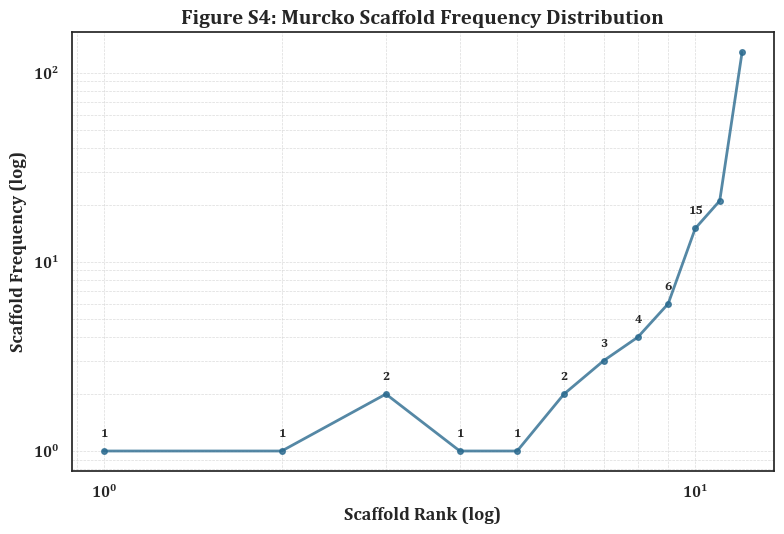

In [ ]:
# Murcko Scaffold Analysis - Supplymental Figure 
# 假设你已经有 scaffold_counts 这个 Series（每个 scaffold 出现的次数）

# 计算频率分布
scaffold_freq = scaffold_counts.value_counts().sort_index(ascending=False)

# 创建 rank-frequency plot
fig, ax = plt.subplots(figsize=(8, 5.5))

# 主图：Rank vs Frequency (log-log)
ranks = np.arange(1, len(scaffold_freq) + 1)
frequencies = scaffold_freq.values

ax.plot(ranks, frequencies, 'o-', color='#2A6A8F', lw=2, markersize=4, alpha=0.8)

# 可选：添加前10个高频 scaffold 的标注
top_n = 10
for i in range(min(top_n, len(ranks))):
    ax.annotate(f'{frequencies[i]}', 
                xy=(ranks[i], frequencies[i]),
                xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Scaffold Rank (log)', fontsize=13)
ax.set_ylabel('Scaffold Frequency (log)', fontsize=13)
ax.set_title('Murcko Scaffold Frequency Distribution', fontsize=15)

# 网格线
ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.7)

# 加粗所有字体
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig(output_dir / "Figure_S4_murcko_scaffold_distribution.svg", 
            bbox_inches='tight', dpi=300)
print("Figure S4 saved: Murcko Scaffold Distribution")
plt.show()

In [ ]:
# 16. Representative Molecule Selection
from scipy.spatial.distance import cdist

representatives = []

for cid in sorted(df['cluster_id'].unique()):
    subset = df[df['cluster_id'] == cid]
    
    # 优先选 active
    subset_active = subset[subset['label'] == 1]
    if len(subset_active) > 0:
        subset = subset_active
    
    coords = subset[['tsne_1', 'tsne_2']].values
    center = coords.mean(axis=0)
    
    dists = cdist(coords, [center]).flatten()
    idx = np.argmin(dists)
    
    representatives.append(subset.iloc[idx])

rep_df = pd.DataFrame(representatives)

In [ ]:
# %% 17. Publication-Ready Grid
from rdkit.Chem.Draw import rdMolDraw2D

def draw_polished_grid_fixed(mols, legends, mols_per_row=4, sub_img_size=(300, 300)):
    num_mols = len(mols)
    num_rows = (num_mols + mols_per_row - 1) // mols_per_row
    
    full_width = mols_per_row * sub_img_size[0]
    full_height = num_rows * sub_img_size[1]
    
    # 1. 创建画布
    drawer = rdMolDraw2D.MolDraw2DSVG(full_width, full_height, sub_img_size[0], sub_img_size[1])
    options = drawer.drawOptions()

    options.backgroundColour = (1, 1, 1, 1)
    options.bondLineWidth = 2.5       # 显著加粗
    options.minFontSize = 14          # 增大原子标签最小字号
    options.maxFontSize = 18
    options.legendFontSize = 18       # 增大图注字号
    options.addStereoAnnotation = True
    options.fixedFontSize = 16        # 锁定字号防止缩放不一
    options.padding = 0.15            # 增加边距，防止分子太挤
    
    # 2. 逐个分子手动定位绘制
    for i, (mol, legend) in enumerate(zip(mols, legends)):
        if mol is None: continue
        
        # 计算当前分子所在的单元格位置
        row = i // mols_per_row
        col = i % mols_per_row
        
        # 预处理分子坐标（关键：确保对齐方向一致）
        tm = rdMolDraw2D.PrepareMolForDrawing(mol)
        
        # 指定绘制区域
        drawer.SetOffset(col * sub_img_size[0], row * sub_img_size[1])
        drawer.DrawMolecule(tm, legend=legend)
    
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

# 准备数据
mols_to_draw = [Chem.MolFromSmiles(s) for s in rep_df['smiles']]
polished_legends = [
    f"C{int(row['cluster_id'])} ({'Active' if row['label']==1 else 'Inactive'})"
    for _, row in rep_df.iterrows()
]

# 执行重绘
final_svg = draw_polished_grid_fixed(mols_to_draw, polished_legends)

# 保存
with open(output_dir / "Figure_3_representative_molecules_polished.svg", "w") as f:
    f.write(final_svg)

print(f"Done! {len(mols_to_draw)} molecules drawn in SVG and save to {output_dir / 'Figure_3_representative_molecules_polished.svg'}")


Done! 8 molecules drawn in SVG and save to cluster/Figure_3_representative_molecules_polished.svg


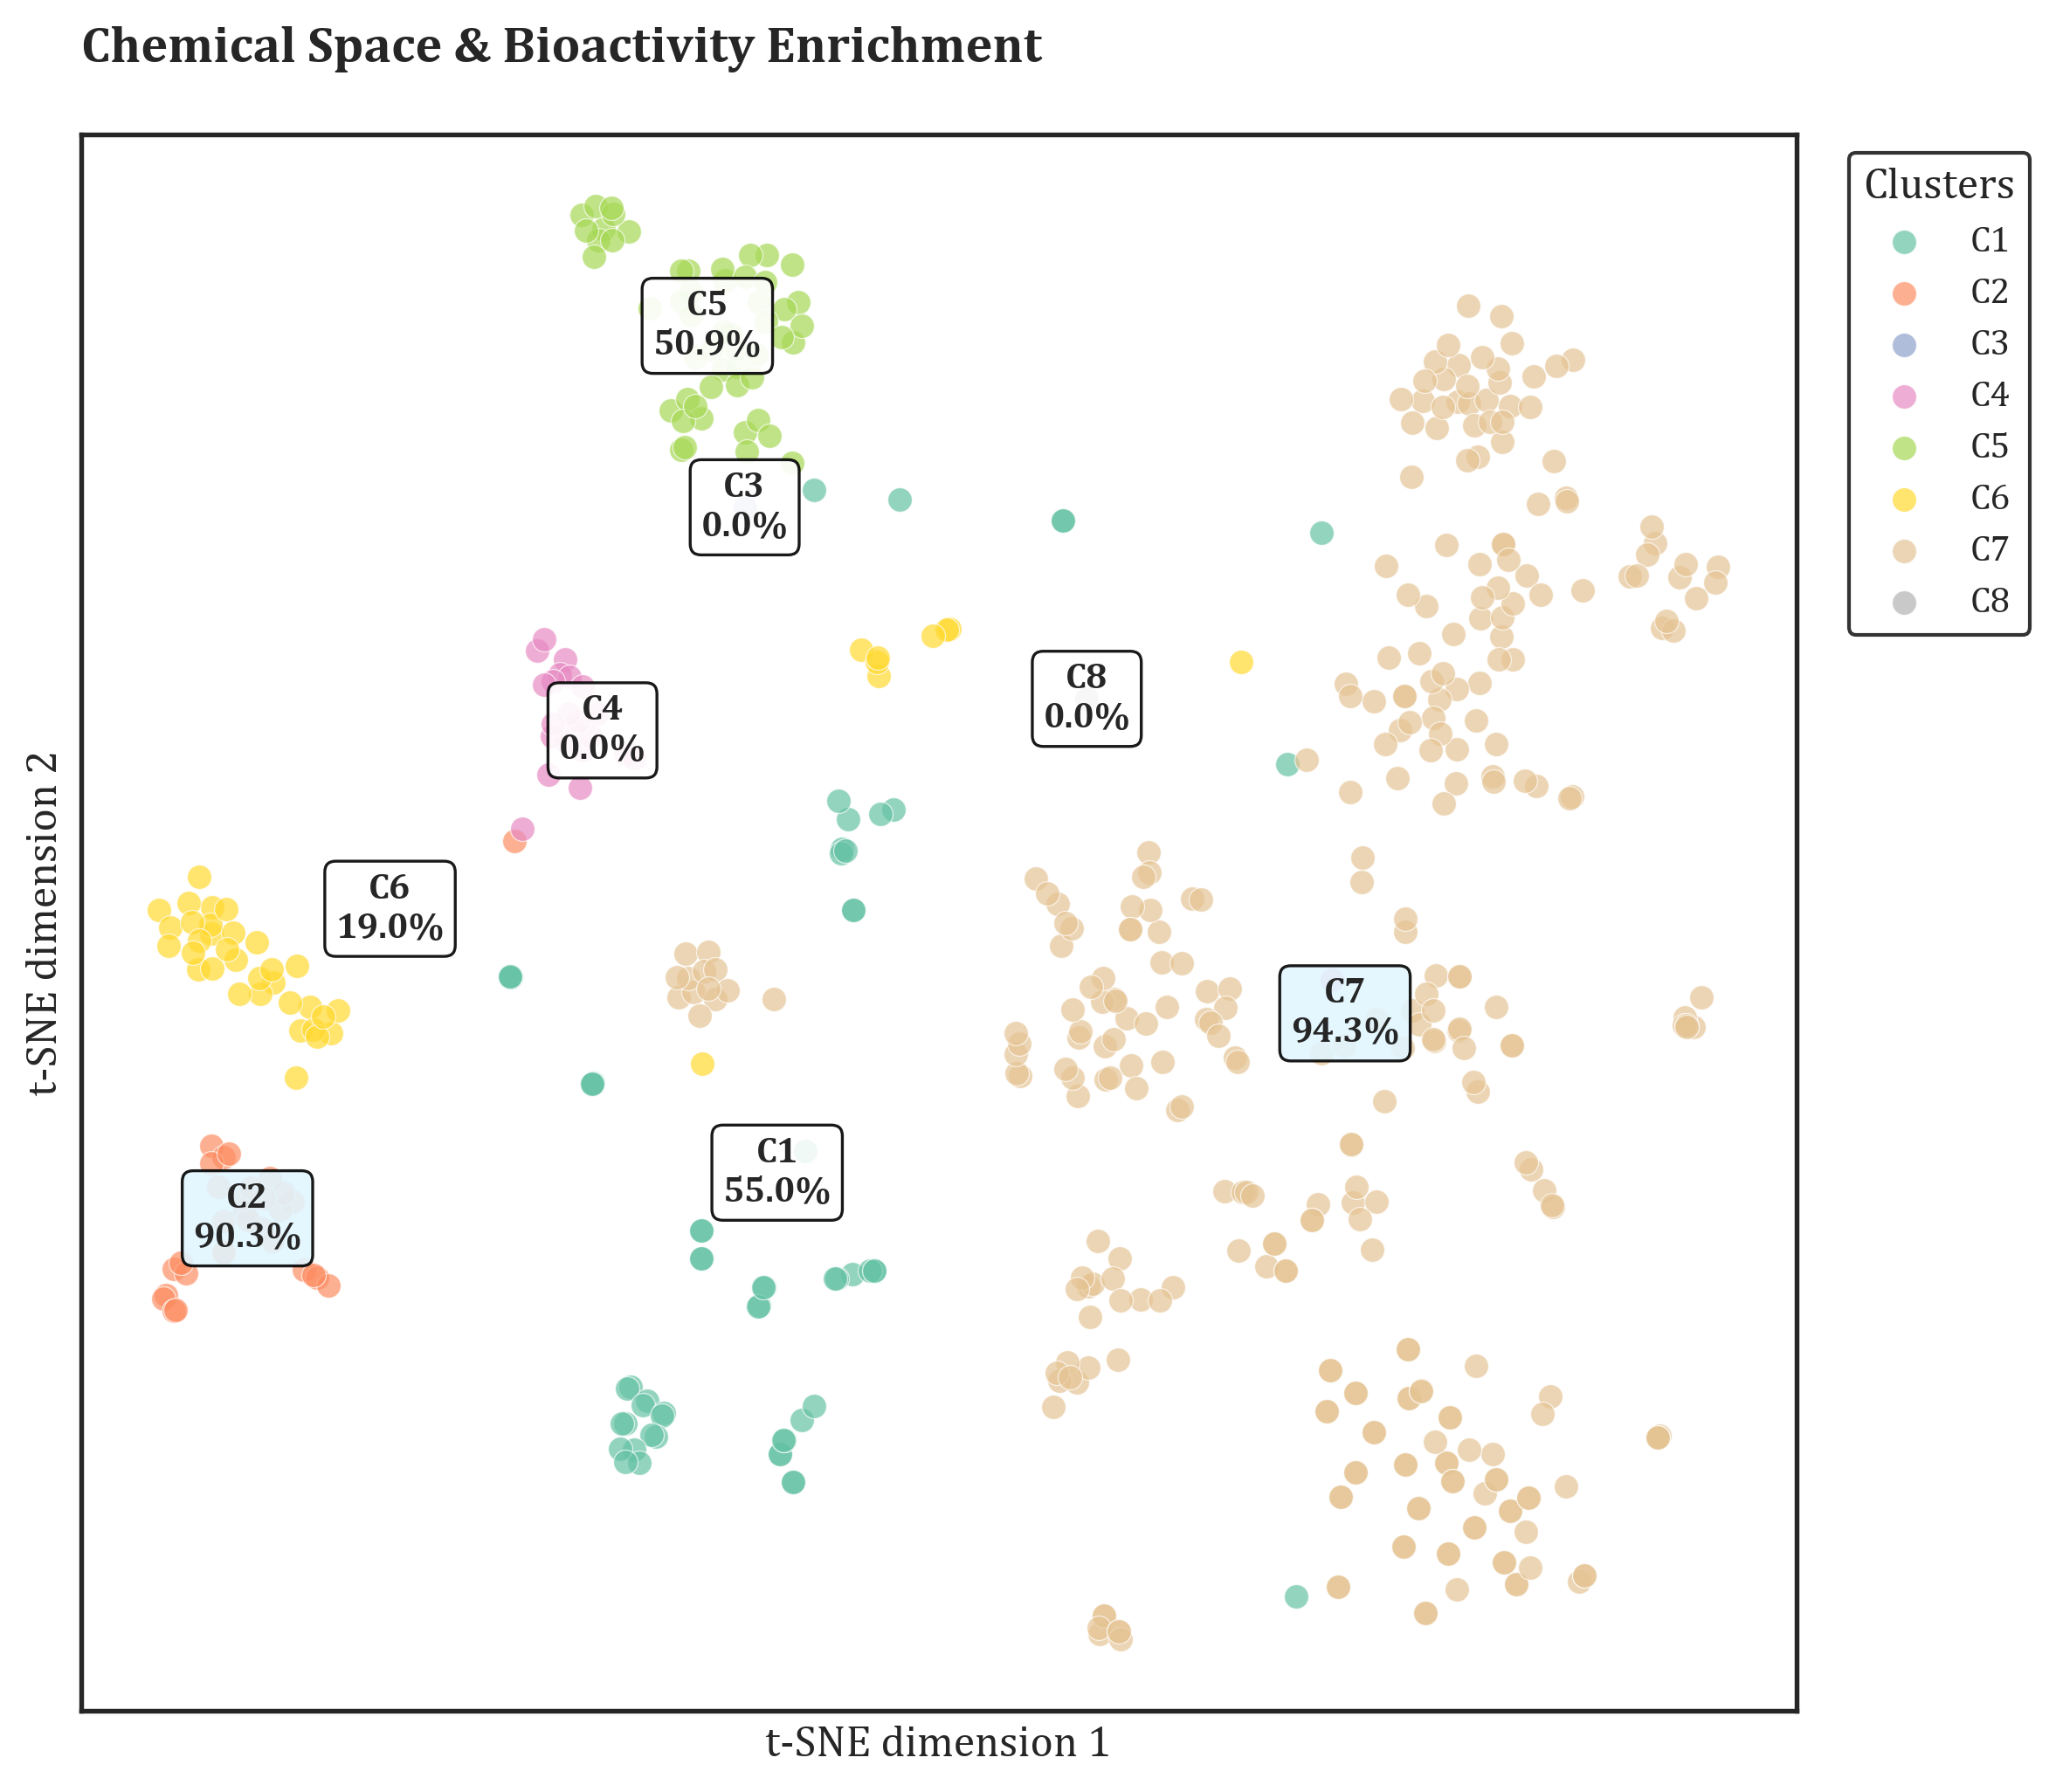

In [36]:
# 18. t-SNE Plot with Cluster + Enrichment (Optimized for Publication)
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

# 使用更专业的色板
cluster_palette = sns.color_palette("Set2", manual_k)

for i, cid in enumerate(sorted(df['cluster_id'].unique())):
    subset = df[df['cluster_id'] == cid]
    ax.scatter(
        subset['tsne_1'], subset['tsne_2'],
        color=cluster_palette[i],
        s=45, alpha=0.7,
        edgecolors='white', linewidths=0.3,
        label=f'C{cid}',
        zorder=1
    )

# 标注优化：增加颜色深浅区分富集度
for cid in sorted(df['cluster_id'].unique()):
    subset = df[df['cluster_id'] == cid]
    x, y = subset['tsne_1'].mean(), subset['tsne_2'].mean()
    ratio = enrichment.loc[cid]
    
    # 根据活性比例自动调整框的颜色：高活性用浅蓝色背景突出
    box_color = '#E1F5FE' if ratio > df['label'].mean() else 'white'
    
    ax.text(
        x, y,
        f"C{cid}\n{ratio:.1%}", # 使用百分比展示更直观
        fontsize=10, fontweight='bold',
        ha='center', va='center',
        zorder=3,
        bbox=dict(
            boxstyle='round,pad=0.3', 
            fc=box_color, 
            ec='black', 
            lw=0.8, 
            alpha=0.9
        )
    )

# 细节美化
ax.set_title('Chemical Space & Bioactivity Enrichment', loc='left', fontweight='bold', pad=20)
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')

# 延续你的全封闭箱式风格
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(1.3)

ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(direction='out', top=True, right=True, length=4)

# 调整图例到右侧外，防止遮挡
ax.legend(title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='black')

plt.tight_layout()
plt.savefig(output_dir / "Figure_2_TSNE_Enrichment_Polished.svg", bbox_inches='tight')
plt.show()

/tmp/ipykernel_375712/2988728937.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


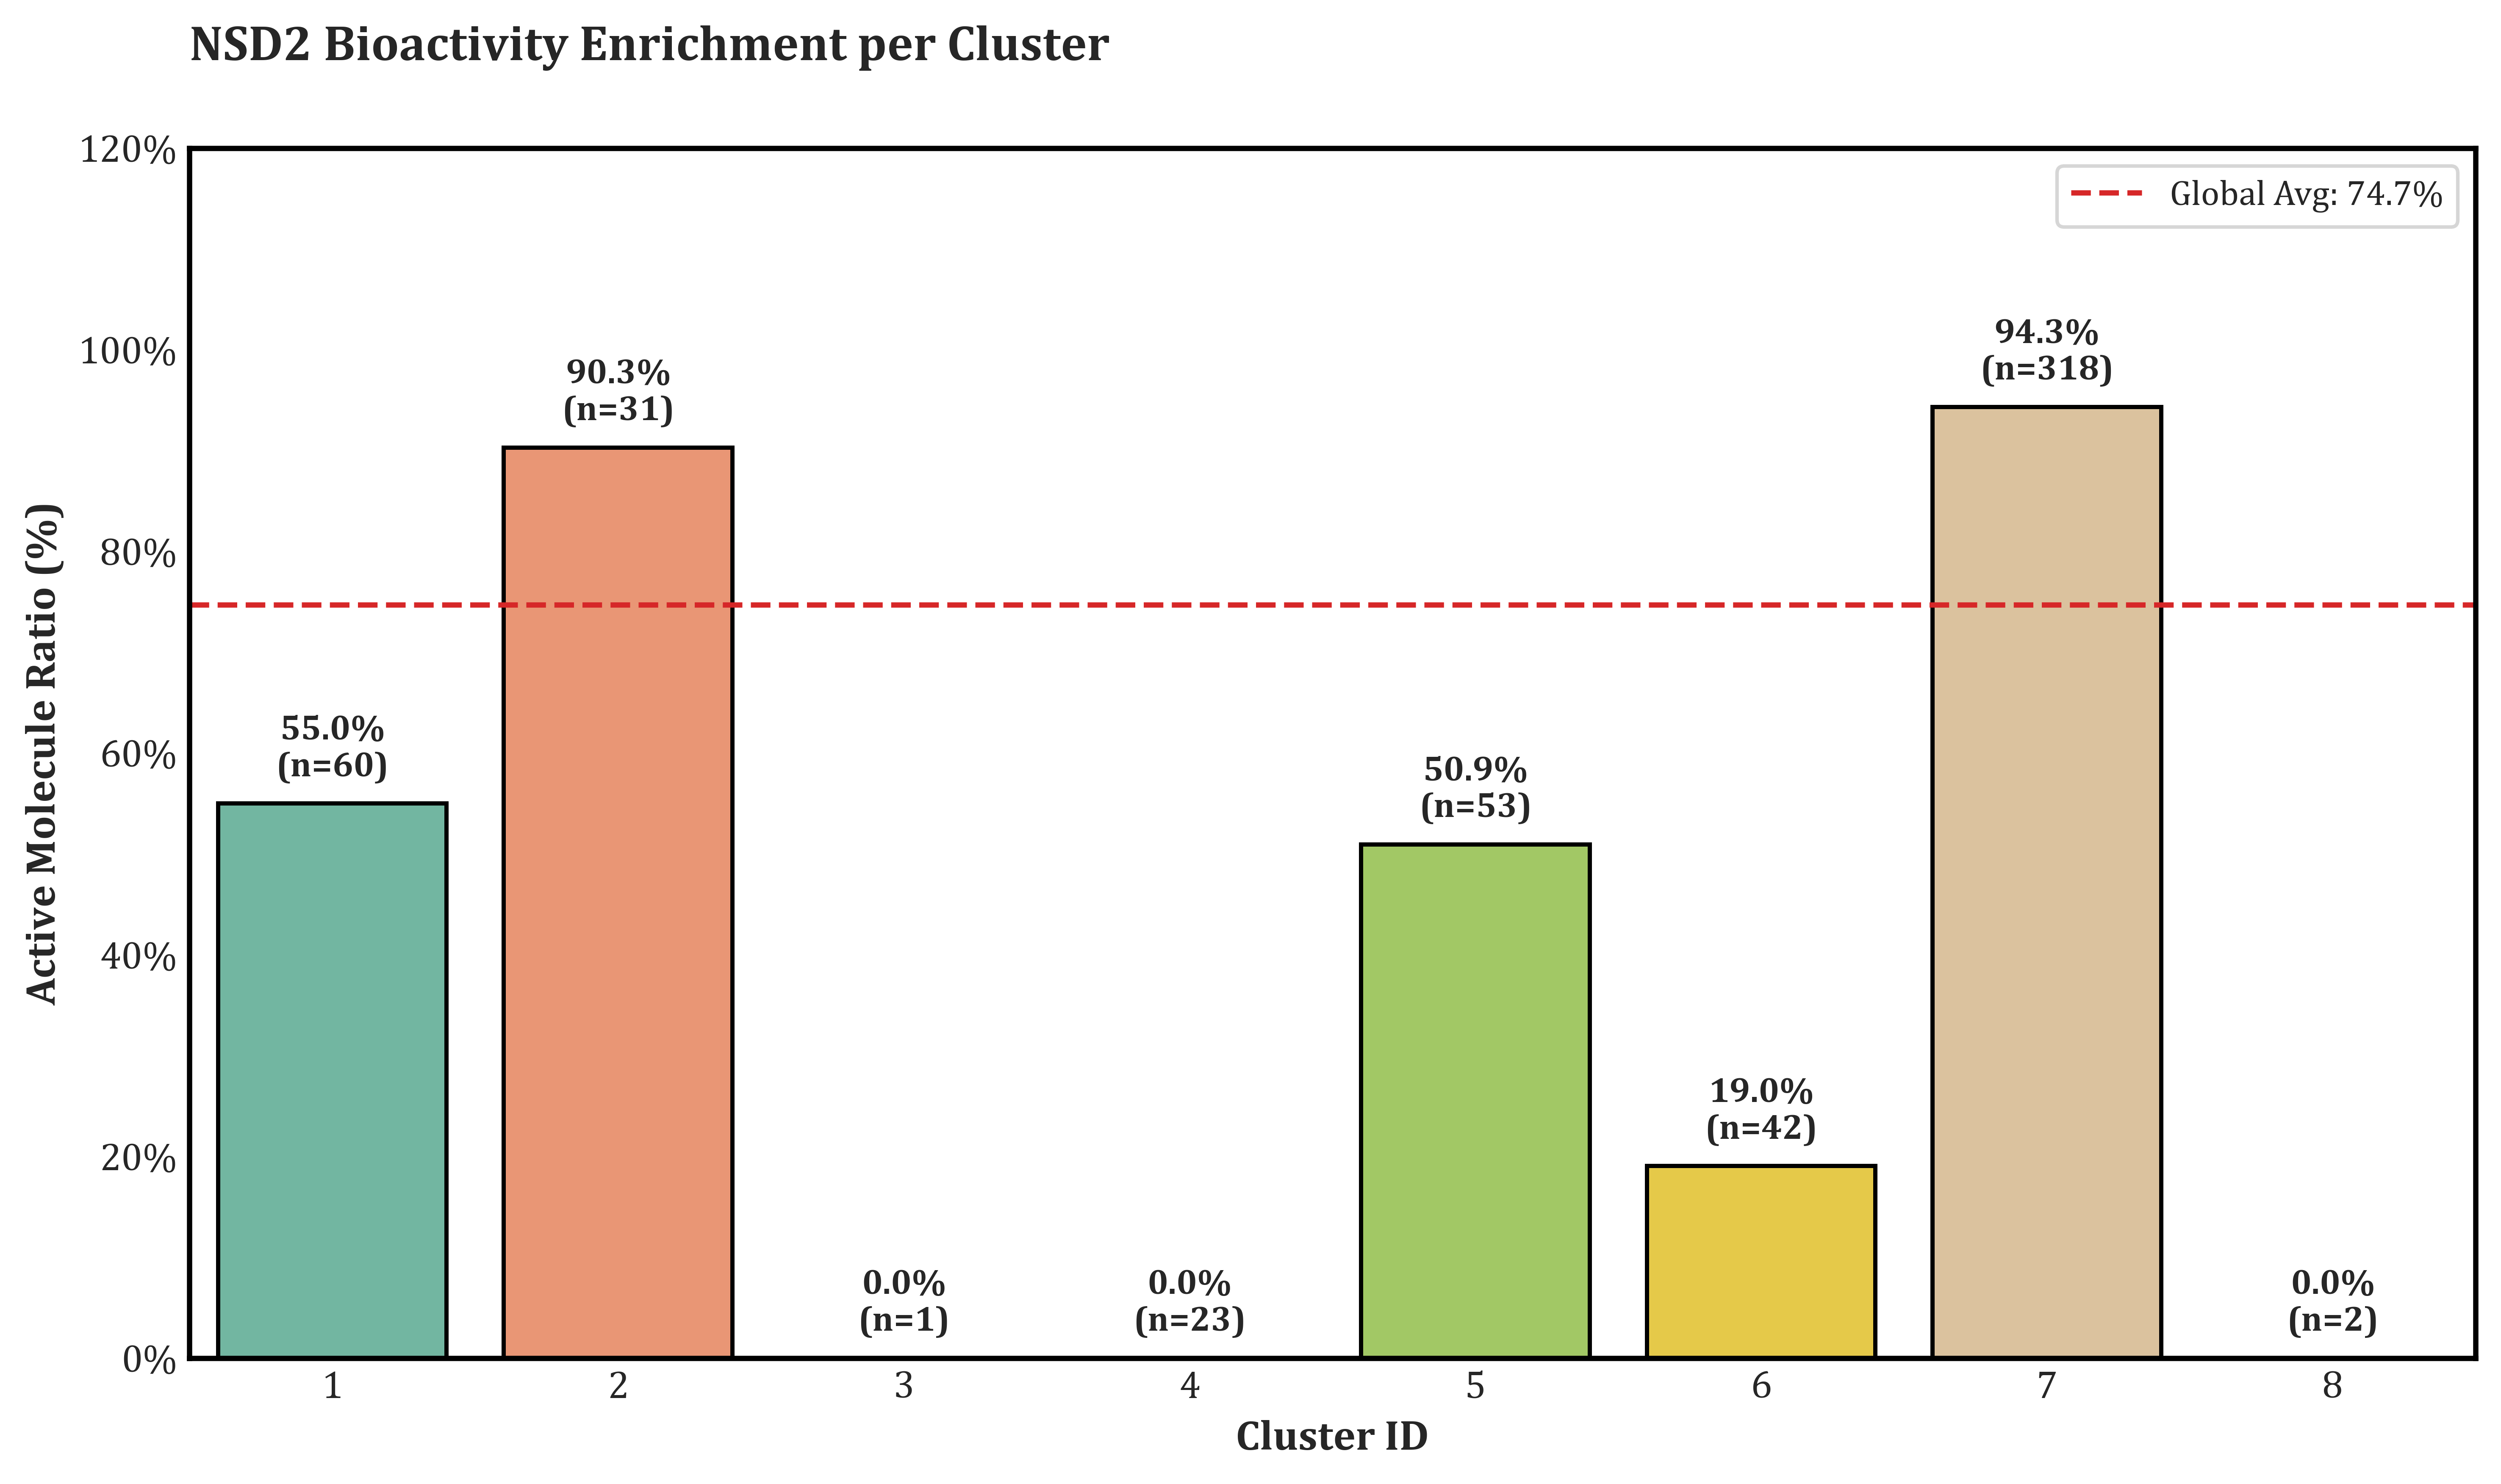

In [ ]:
# %% 19
import matplotlib.ticker as mtick

# 1. 重新准备数据，确保不被之前的排序干扰
# 直接按 cluster_id 从小到大排序，确保与坐标轴顺序一致
res_df = df.groupby('cluster_id')['label'].agg(['mean', 'size']).reset_index()
res_df.columns = ['cluster_id', 'active_ratio', 'count']
res_df = res_df.sort_values('cluster_id') 

avg_ratio = df['label'].mean() 

plt.figure(figsize=(10, 6), dpi=600)

# 使用 Set2 色板，确保与 t-SNE 颜色一致
cluster_palette = sns.color_palette("Set2", len(res_df))

ax = sns.barplot(
    x='cluster_id', 
    y='active_ratio', 
    data=res_df, 
    palette=cluster_palette,
    edgecolor='black',
    linewidth=1.2
)

# 2. 使用 enumerate 确保标注的是当前的 bar
for i, p in enumerate(ax.patches):
    # 此时 i 对应 res_df 的行索引
    row = res_df.iloc[i]
    ratio = row['active_ratio']
    n_total = int(row['count'])
    
    # 获取柱子中心位置
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    
    # 只在有高度的情况下标注（或 0% 也标注在底部）
    ax.text(x, y + 0.02, f'{ratio:.1%}\n(n={n_total})', 
            ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

# 3. 辅助线与美化
plt.axhline(y=avg_ratio, color='#D62728', linestyle='--', linewidth=1.5, 
            label=f'Global Avg: {avg_ratio:.1%}')

# 4. 视觉优化与边框加固
plt.title('(c) NSD2 Bioactivity Enrichment per Cluster', loc='left', fontweight='bold', pad=25, fontsize=14)
plt.ylabel('Active Molecule Ratio (%)', fontsize=12, fontweight='bold')
plt.xlabel('Cluster ID', fontsize=12, fontweight='bold')
plt.ylim(0, 1.2) # 增加顶部空白空间

# 强制显示四面边框 (满足全封闭要求)
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(1.5)
    ax.spines[spine].set_color('black')

# 格式化 Y 轴
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(direction='in', length=6, width=1.2, top=False, right=False) # 刻度线

# 5. 图例优化：移到图表右侧外，防止遮挡
#plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='black', fontsize=10)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig(output_dir / "Figure_S3_enrichment_bar_polished.svg", bbox_inches='tight')
plt.show()

In [42]:
# 20. Save Key Tables
top_scaffold.to_csv(output_dir / "top_scaffolds.csv", index=False)
rep_df.to_csv(output_dir / "representative_molecules.csv", index=False)

print("\nAll outputs saved to:", output_dir)



All outputs saved to: cluster
